<a href="https://colab.research.google.com/github/Elvis-Kayonga/Data-Preprocessing-Formative2-ML-GROUP9/blob/main/notebooks/product_recommendation_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Product Recommendation Model
## Multimodal Data Preprocessing — Group 9

This notebook builds a product recommendation model using merged customer data.
The pipeline covers three stages:
1. Loading and merging two data sources (social profiles + transactions)
2. Cleaning, feature engineering, and exploratory data analysis
3. Training and evaluating an XGBoost classifier to predict product categories


In [1]:
#Importing libraries
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import joblib
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load the Datasets

We are working with two separate data sources:
- **customer_social_profiles**: contains each customer's social media platform,
  engagement score, purchase interest score, and review sentiment.
- **customer_transactions**: contains transaction-level records including purchase
  amount, date, product category, and customer rating.

These two sources share customer IDs but use different formats — the social profiles
use an `A`-prefixed string (e.g. `A190`) while transactions use a plain integer.
We strip the prefix before merging.

In [2]:

# Load datasets
social_data = pd.read_csv("customer_social_profiles.csv")
trans_data = pd.read_csv("customer_transactions.csv")

print("Social Data:")
print(social_data.head())

print("\nTransaction Data:")
print(trans_data.head())

Social Data:
  customer_id_new social_media_platform  engagement_score  \
0            A178              LinkedIn                74   
1            A190               Twitter                82   
2            A150              Facebook                96   
3            A162               Twitter                89   
4            A197               Twitter                92   

   purchase_interest_score review_sentiment  
0                      4.9         Positive  
1                      4.8          Neutral  
2                      1.6         Positive  
3                      2.6         Positive  
4                      2.3          Neutral  

Transaction Data:
   customer_id_legacy  transaction_id  purchase_amount purchase_date  \
0                 151            1001              408    2024-01-01   
1                 192            1002              332    2024-01-02   
2                 114            1003              442    2024-01-03   
3                 171            1004

## Step 2: Merge the Datasets

We convert the ID formats to match, then perform an **inner join** on `customer_id`.
An inner join means we only keep customers who appear in **both** datasets — ensuring
every row in the merged data has complete social and transaction information.

We print the shape and a preview after merging to confirm the join worked correctly.

In [7]:
# Convert IDs to same format

social_data['customer_id'] = social_data['customer_id_new'].str.replace('A', '').astype(int)
trans_data['customer_id'] = trans_data['customer_id_legacy']

# Merge datasets
merged_data = pd.merge(social_data, trans_data, on='customer_id', how='inner')


# ── Post-Merge Validation ──────────────────────────────────────────
print("=== Post-Merge Validation ===\n")

# Shape before vs after
print(f"Social profiles rows:   {len(social_data)}")
print(f"Transactions rows:      {len(trans_data)}")
print(f"Merged dataset rows:    {len(merged_data)}")
print(f"Merged dataset columns: {merged_data.shape[1]}\n")

# Check for null values introduced by the join
null_counts = merged_data.isnull().sum()
print("Null values per column:")
print(null_counts[null_counts > 0] if null_counts.any() else "  None — clean merge!")
print()

# Check for duplicate customer transaction pairs
dupes = merged_data.duplicated(subset=['customer_id', 'transaction_id']).sum()
print(f"Duplicate (customer_id, transaction_id) pairs: {dupes}")

# Confirm join coverage — how many unique customers matched?
matched = merged_data['customer_id'].nunique()
total_social = social_data['customer_id'].nunique()
print(f"Customers matched: {matched} out of {total_social} in social profiles")
print(f"Join retention rate: {matched/total_social*100:.1f}%")

merged_data.info()
print(merged_data.head())

=== Post-Merge Validation ===

Social profiles rows:   155
Transactions rows:      150
Merged dataset rows:    219
Merged dataset columns: 12

Null values per column:
customer_rating    19
dtype: int64

Duplicate (customer_id, transaction_id) pairs: 102
Customers matched: 61 out of 84 in social profiles
Join retention rate: 72.6%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id_new          219 non-null    object 
 1   social_media_platform    219 non-null    object 
 2   engagement_score         219 non-null    int64  
 3   purchase_interest_score  219 non-null    float64
 4   review_sentiment         219 non-null    object 
 5   customer_id              219 non-null    int64  
 6   customer_id_legacy       219 non-null    int64  
 7   transaction_id           219 non-null    int64  
 8   purchase_amount   

#Visualisations

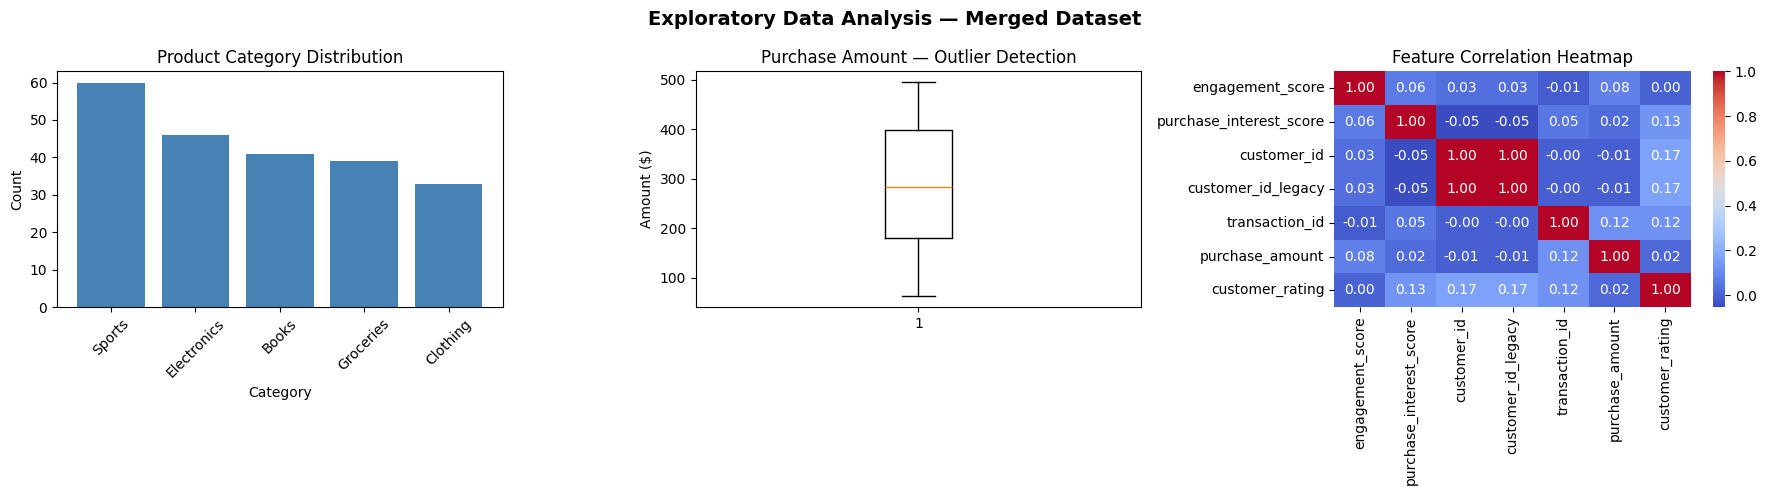


Key observations:
  - Most common product category: Sports (60 purchases)
  - Average purchase amount: $288.38
  - Purchase amount range: $62 – $495
  - Highest correlation pair found in heatmap above


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis — Merged Dataset", fontsize=14, fontweight='bold')

# Plot 1: Distribution of product categories (target variable)
category_counts = merged_data['product_category'].value_counts()
axes[0].bar(category_counts.index, category_counts.values, color='steelblue')
axes[0].set_title("Product Category Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Purchase amount distribution (outlier detection)
axes[1].boxplot(merged_data['purchase_amount'].dropna())
axes[1].set_title("Purchase Amount — Outlier Detection")
axes[1].set_ylabel("Amount ($)")

# Plot 3: Correlation heatmap of numeric features
numeric_cols = merged_data.select_dtypes(include='number')
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[2], cbar=True)
axes[2].set_title("Feature Correlation Heatmap")

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nKey observations:")
print(f"  - Most common product category: {category_counts.idxmax()} ({category_counts.max()} purchases)")
print(f"  - Average purchase amount: ${merged_data['purchase_amount'].mean():.2f}")
print(f"  - Purchase amount range: ${merged_data['purchase_amount'].min()} – ${merged_data['purchase_amount'].max()}")
print(f"  - Highest correlation pair found in heatmap above")

In [8]:
#save merged_dataset
merged_data.to_csv("merged_dataset.csv", index=False)
print("Merged dataset saved!")

Merged dataset saved!


#Data Cleaning and processing

In [9]:
# Fill missing ratings with median
merged_data['customer_rating'].fillna(merged_data['customer_rating'].median(), inplace=True)

# Check nulls
merged_data.isnull().sum()

/tmp/ipykernel_2528/2435663639.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data['customer_rating'].fillna(merged_data['customer_rating'].median(), inplace=True)


,0
customer_id_new,0
social_media_platform,0
engagement_score,0
purchase_interest_score,0
review_sentiment,0
customer_id,0
customer_id_legacy,0
transaction_id,0
purchase_amount,0
purchase_date,0


In [10]:

#  Transform date
merged_data['purchase_date'] = pd.to_datetime(merged_data['purchase_date'])

merged_data['purchase_month'] = merged_data['purchase_date'].dt.month
merged_data['purchase_day'] = merged_data['purchase_date'].dt.day

# Drop useless columns
merged_data = merged_data.drop([
    'customer_id_new',
    'customer_id',
    'customer_id_legacy',
    'transaction_id',
    'purchase_date'
], axis=1)

#  Separate target
y = merged_data['product_category']
X = merged_data.drop('product_category', axis=1)

# 5. Encode categorical columns
X = pd.get_dummies(X, columns=[
    'social_media_platform',
    'review_sentiment'
]).astype(int)

print(X.head())

joblib.dump(X.columns, "model_columns.pkl")
print("model_columns.pkl saved successfully")

   engagement_score  purchase_interest_score  purchase_amount  \
0                82                        4              333   
1                82                        4              401   
2                96                        1              389   
3                96                        1              177   
4                89                        2              101   

   customer_rating  purchase_month  purchase_day  \
0                3               1            31   
1                4               5            19   
2                3               2            11   
3                3               2            15   
4                4               3            19   

   social_media_platform_Facebook  social_media_platform_Instagram  \
0                               0                                0   
1                               0                                0   
2                               1                                0   
3               

#Splitting the data

In [11]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Encode target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Save the label encoder
joblib.dump(label_encoder, "product_label_encoder.pkl")
print("product_label_encoder.pkl saved successfully")


product_label_encoder.pkl saved successfully


#Train XGB Model

In [12]:
# Define XGBoost classifier
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    max_depth=5,
    learning_rate=0.1,
    n_estimators=200,
    random_state=42,
    eval_metric='mlogloss'
)

# Train model
model.fit(X_train, y_train_encoded)

# Predict
y_pred_encoded = model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Save the model
joblib.dump(model, "product_xgb_model.pkl")
print("product_xgb_model.pkl saved successfully")

product_xgb_model.pkl saved successfully


#Evaluating the model

In [13]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.6590909090909091
F1 Score: 0.6569937239793698

Classification Report:
               precision    recall  f1-score   support

       Books       0.56      0.50      0.53        10
    Clothing       0.67      0.50      0.57         4
 Electronics       0.58      0.78      0.67         9
   Groceries       0.70      0.78      0.74         9
      Sports       0.80      0.67      0.73        12

    accuracy                           0.66        44
   macro avg       0.66      0.64      0.65        44
weighted avg       0.67      0.66      0.66        44

[[5 0 3 2 0]
 [0 2 0 0 2]
 [0 1 7 1 0]
 [2 0 0 7 0]
 [2 0 2 0 8]]
